In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
import astropy.units as u

from pathlib import Path


In [47]:
INPUT_PATH = Path("~/Research/AsTrovello/Input/").expanduser()
hst_suffix = "PHANGS-HST/galaxies/ngc1087/hlsp_phangs-hst_hst_wfc3-uvis_ngc1087_f814w_v1_exp-drc-sci.fits"
jwst_suffix = "PHANGS-JWST/galaxies/ngc1087/hlsp_phangs-jwst_jwst_nircam_ngc1087_f200w_v1p1_img.fits"

hst_file = INPUT_PATH / hst_suffix
jwst_file = INPUT_PATH / jwst_suffix


In [48]:
with fits.open(hst_file) as hdu_hst, fits.open(jwst_file) as hdu_jwst:
    data_hst = hdu_hst[0].data
    header_hst = hdu_hst[0].header
    
    data_jwst = hdu_jwst[1].data
    header_jwst = hdu_jwst[1].header
    

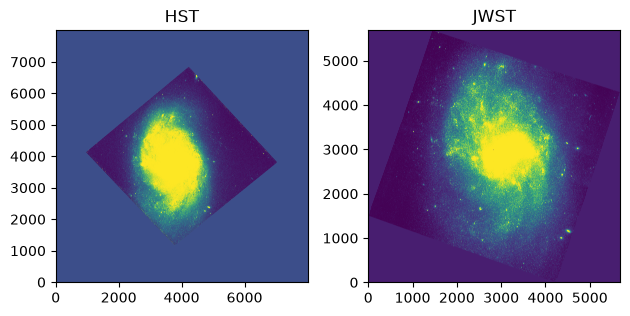

In [49]:
min_hst, max_hst = np.percentile(data_hst, [5, 95])
min_jwst, max_jwst = np.percentile(data_jwst, [5, 95])

fig, (ax1, ax2) = plt.subplots(1,2)
ax1.imshow(data_hst, cmap="viridis", origin="lower", vmin=min_hst, vmax=max_hst)
ax2.imshow(data_jwst, cmap="viridis", origin="lower", vmin=min_jwst, vmax=max_jwst)
ax1.set_title("HST")
ax2.set_title("JWST")
plt.tight_layout()
plt.show()


In [50]:
mean_hst, median_hst, std_hst = sigma_clipped_stats(data_hst, sigma=3.0, maxiters=5)
mean_jwst, median_jwst, std_jwst = sigma_clipped_stats(data_jwst, sigma=3.0, maxiters=5)

hst_dict = {"telescope": "HST", "mean": mean_hst, "median": median_hst, "std": std_hst}
jwst_dict = {"telescope": "JWST", "mean": mean_jwst, "median": median_jwst, "std": std_jwst}



In [51]:
df = pd.DataFrame([hst_dict, jwst_dict]).set_index("telescope")
print(df.to_string(float_format=lambda x: f"{x:.4e}"))

                 mean     median        std
telescope                                  
HST       -2.6647e-04 0.0000e+00 2.7948e-03
JWST       5.1636e-02 0.0000e+00 1.6925e-01


In [52]:
sky_subtracted_hst = data_hst - median_hst
sky_subtracted_jwst = data_jwst - median_jwst

daofind_hst = DAOStarFinder(fwhm = 2.5, threshold = 30 * std_hst)
daofind_jwst = DAOStarFinder(fwhm = 2.5, threshold = 30 * std_jwst)

In [53]:
sources_hst = daofind_hst(sky_subtracted_hst)
sources_jwst = daofind_jwst(sky_subtracted_hst)

In [58]:
mask_hst = (
    (sources_hst['sharpness'] > 0.1) & (sources_hst['sharpness'] < 1.2) &
    (sources_hst['roundness2'] > -0.3) & (sources_hst['roundness2'] < 0.3)
)
mask_jwst = (
    (sources_jwst['sharpness'] > 0.1) & (sources_jwst['sharpness'] < 1.2) &
    (sources_jwst['roundness2'] > -0.3) & (sources_jwst['roundness2'] < 0.3)
)
sources_hst_clean = sources_hst[mask_hst]
sources_jwst_clean = sources_jwst[mask_jwst]

In [59]:
wcs_hst = WCS(header_hst)
wcs_jwst = WCS(header_jwst)

coords_hst = wcs_hst.pixel_to_world(sources_hst_clean["x_centroid"], sources_hst_clean["y_centroid"])
coords_jwst = wcs_jwst.pixel_to_world(sources_jwst_clean["x_centroid"], sources_jwst_clean["y_centroid"])

idx, d2d, d3d = coords_hst.match_to_catalog_sky(coords_jwst)


Set DATE-AVG to '2023-01-25T13:51:14.748' from MJD-AVG.
Set DATE-END to '2023-01-25T14:18:58.995' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to     9.622808 from OBSGEO-[XYZ].
Set OBSGEO-H to 1660472184.749 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [60]:
d2d

<Angle [0.01997889, 0.01989281, 0.01961673, ..., 0.00641401, 0.00661894,
        0.00671619] deg>

In [61]:
# 1. Conversões básicas após o match_to_catalog_sky
separacao_arcsec = d2d.arcsec
coarse_pixel_scale = 0.04  # arcsec/pixel
offsets_pixels = separacao_arcsec / coarse_pixel_scale

# 2. Definir a máscara de fontes válidas (filtrando quem está muito longe)
limite_maximo = 0.2  # arcsec
validos = separacao_arcsec < limite_maximo

# 3. Aplicar o filtro e calcular a mediana
offsets_validos = offsets_pixels[validos]

print(f"Offsets individuais (em pixels): {offsets_validos[:5]}")
print(f"Offset mediano das fontes: {np.median(offsets_validos):.2f} pixels")

Offsets individuais (em pixels): []
Offset mediano das fontes: nan pixels


/opt/homebrew/Caskroom/miniconda/base/envs/capivara/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/homebrew/Caskroom/miniconda/base/envs/capivara/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


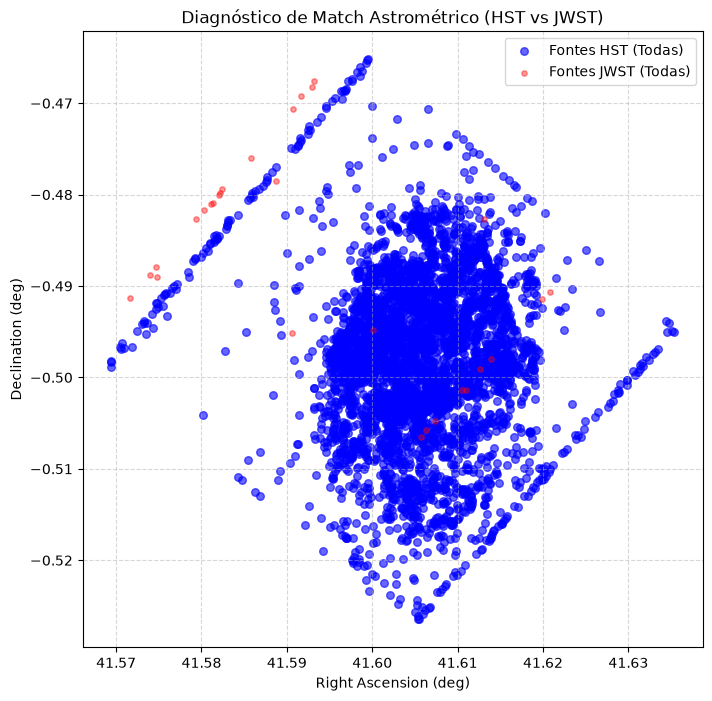

In [62]:
# Converte as coordenadas celestes para graus para facilitar o plot
ra_hst, dec_hst = coords_hst.ra.deg, coords_hst.dec.deg
ra_jwst, dec_jwst = coords_jwst.ra.deg, coords_jwst.dec.deg

plt.figure(figsize=(8, 8))

# Plota todas as fontes detectadas (para ver o campo geral)
plt.scatter(ra_hst, dec_hst, color='blue', s=30, alpha=0.6, label='Fontes HST (Todas)')
plt.scatter(ra_jwst, dec_jwst, color='red', s=15, alpha=0.4, label='Fontes JWST (Todas)')

# Plota linhas conectando os pares válidos que o match encontrou
for i in range(len(coords_hst)):
    if validos[i]:  # Apenas os pares que passaram no filtro de 0.2 arcsec
        plt.plot([ra_hst[i], ra_jwst[idx[i]]], 
                 [dec_hst[i], dec_jwst[idx[i]]], 
                 color='green', linestyle='-', alpha=0.7)

plt.xlabel('Right Ascension (deg)')
plt.ylabel('Declination (deg)')
plt.title('Diagnóstico de Match Astrométrico (HST vs JWST)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()